# Sentence Segmentation Experiment

This notebook experiments with sentence segmentation using SpaCy and a custom method for English language.

In [1]:
import subprocess

def install_spacy_model():
   subprocess.run(["uv", "run", "spacy", "download", "en_core_web_sm"])
    
install_spacy_model()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 35.1 MB/s eta 0:00:000:00:0136m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [1]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/yann.hallouard/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Import

In [1]:
from datasets import load_dataset  # type: ignore[import-untyped]

# Load Dataset

In [2]:
wikipedia_dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.en",
    split="train",
)
iter_wikipedia_dataset = iter(wikipedia_dataset)

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/41 [00:00<?, ?it/s]

In [3]:
article = next(iter_wikipedia_dataset)

# Experiment spliting

In [4]:
import spacy
import re

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

def spacy_segment(text: str) -> list[str]:
    doc = nlp(text)
    return [sent.text.strip().replace("\n", " ") for sent in doc.sents]

def custom_resplit(text: str, max_length: int) -> list[str]:
    words = text.split()
    result = []
    current_piece = ''
    for word in words:
        if len(current_piece) + len(word) + 1 <= max_length:
            current_piece += (word + ' ')
        else:
            result.append(current_piece.strip())
            current_piece = word + ' '
    if current_piece:
        result.append(current_piece.strip())
    return result

def spliter(text: str, max_length: int) -> list[str]:
    sentences = []
    for sent in spacy_segment(text):
        if len(sent) < max_length:
            sentences.append(sent)
        else:
            sentences.extend(custom_resplit(sent, max_length))
    return sentences

# Example text
text = 'This is a long sentence that needs to be split into smaller parts. It should be split correctly.'

# Segment using SpaCy
spacy_segments = spacy_segment(text)
print('SpaCy Segments:', spacy_segments)

# Segment using custom method
custom_segments = custom_resplit(text, max_length=50)
print('Custom Segments:', custom_segments)


SpaCy Segments: ['This is a long sentence that needs to be split into smaller parts.', 'It should be split correctly.']
Custom Segments: ['This is a long sentence that needs to be split', 'into smaller parts. It should be split correctly.']


In [5]:
# Segment using SpaCy
spacy_segments = spacy_segment(article["text"])
print('SpaCy Segments:', spacy_segments)

SpaCy Segments: ['Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism.', 'Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations.', 'As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).', 'Humans have lived in societies without formal hierarchies long before the establishment of states, realms, or empires.', 'With the rise of organised hierarchical bodies, scepticism toward authority also rose.', 'Although traces of anarchist ideas are found all throughout history, modern anarchism emerged from the Enlightenment.', "During the latter half of the 19th and the first decades of the 20t

In [6]:
# Segment using custom method
custom_segments = custom_resplit(article["text"], max_length=50)
print('Custom Segments:', custom_segments)

Custom Segments: ['Anarchism is a political philosophy and movement', 'that is skeptical of all justifications for', 'authority and seeks to abolish the institutions', 'it claims maintain unnecessary coercion and', 'hierarchy, typically including nation-states, and', 'capitalism. Anarchism advocates for the', 'replacement of the state with stateless societies', 'and voluntary free associations. As a', 'historically left-wing movement, this reading of', 'anarchism is placed on the farthest left of the', 'political spectrum, usually described as the', 'libertarian wing of the socialist movement', '(libertarian socialism). Humans have lived in', 'societies without formal hierarchies long before', 'the establishment of states, realms, or empires.', 'With the rise of organised hierarchical bodies,', 'scepticism toward authority also rose. Although', 'traces of anarchist ideas are found all', 'throughout history, modern anarchism emerged from', 'the Enlightenment. During the latter half of t

In [25]:
# Segment both method
custom_segments = spliter(article["text"], max_length=75)
print('Custom Segments:', custom_segments)

Custom Segments: ['Anarchism is a political philosophy and movement that is skeptical of all', 'justifications for authority and seeks to abolish the institutions it', 'claims maintain unnecessary coercion and hierarchy, typically including', 'nation-states, and capitalism.', 'Anarchism advocates for the replacement of the state with stateless', 'societies and voluntary free associations.', 'As a historically left-wing movement, this reading of anarchism is placed', 'on the farthest left of the political spectrum, usually described as the', 'libertarian wing of the socialist movement (libertarian socialism).', 'Humans have lived in societies without formal hierarchies long before the', 'establishment of states, realms, or empires.', 'With the rise of organised hierarchical bodies, scepticism toward', 'authority also rose.', 'Although traces of anarchist ideas are found all throughout history,', 'modern anarchism emerged from the Enlightenment.', 'During the latter half of the 19th and 

# Computing AutoBLEU after sonar

In [8]:
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100DecoderModel, M2M100EncoderModel

sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf")
decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [259]:
from tqdm import tqdm
import torch

embeddings = []
sonar_encoder.to("mps")
for chunk in tqdm(custom_segments[:1]):
    inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True)
    inputs = {k: v.to("mps") for k, v in inputs.items()}
    outputs = sonar_encoder(**inputs).last_hidden_state
    mask = inputs["attention_mask"]
    mean_emb = (outputs * mask.unsqueeze(-1)).sum(1) / mask.unsqueeze(-1).sum(1)
    mean_emb = outputs
    embeddings.append(mean_emb)
    
sonar_encoder.to("cpu")
embeddings = torch.vstack(embeddings).unsqueeze(0)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.87it/s]


In [250]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

doc = []
decoder.to("mps")
for i in tqdm(range(embeddings.shape[1])):
    generator_out = decoder.generate(
        encoder_outputs=BaseModelOutput(last_hidden_state=embeddings[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    doc.append(text_out[0])
decoder.to("cpu")
print(doc)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:44<00:00,  1.12it/s]


['Anarchism is a political philosophy and movement that is skeptical of all justifications for', 'claims maintain unnecessary coercion and hierarchy, typically including nation-stat', 'Anarchism advocates for the replacement of the state with stateless societies', 'As a historically left-wing movement, this reading of anarchism is placed on the', 'libertarian wing of the socialist movement (libertarian socialism).', 'Humans have lived in societies without formal hierarchies long before the establishment of states', 'With the rise of organized hierarchical bodies, skepticism toward authority also rose.', 'Although traces of anarchist ideas are found throughout history, modern anarchism emerged', 'During the latter half of the 19th and the first decades of the 20th century,', "important role in workers' struggles for emancipation.", 'Various anarchist thought schools formed during this period.', 'Anarchists have taken part in several revolutions, most notably in the Paris Com', 'marked t

In [19]:
from tqdm import tqdm
import torch
from transformers.modeling_outputs import BaseModelOutput

def encode_decode(
    text: str,
    max_length: int,
    sonar_tokenizer,
    sonar_encoder,
    decoder
) -> tuple[list[str], list[str]]:
    segments = spliter(text, max_length)
    
    # Encode segments
    sonar_encoder.to("mps")
    embeddings = []
    with torch.no_grad():
        for chunk in tqdm(segments, desc="Encoding"):
            inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True)
            inputs = {k: v.to("mps") for k, v in inputs.items()}
            
            outputs = sonar_encoder(**inputs).last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1)
            mean_emb = (outputs * mask).sum(1) / mask.sum(1)
            
            embeddings.append(mean_emb.detach().cpu())
    
    sonar_encoder.to("cpu")
    
    # Decode embeddings
    doc = []
    decoder.to("mps")
    with torch.no_grad():
        for emb in tqdm(embeddings, desc="Decoding"):
            emb_mps = emb.unsqueeze(1).to("mps")
            
            generator_out = decoder.generate(
                encoder_outputs=BaseModelOutput(last_hidden_state=emb_mps),
                num_beams=5,
                forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
            )
            
            text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
            doc.append(text_out[0])
            
            del emb_mps, generator_out
            torch.mps.empty_cache()
    
    decoder.to("cpu")
    
    return segments, doc

In [20]:
from nltk.translate.bleu_score import sentence_bleu
from textblob import TextBlob

def calculate_autobleu(original_sentences, decoded_sentences):
    scores = []
    for original, decoded in zip(original_sentences, decoded_sentences):
        decoded = str(TextBlob(decoded).correct())
        original = str(TextBlob(original).correct())
        if len(original.split()) > 4:
            score = sentence_bleu([original.split()], decoded.split())
        elif len(original.split()) == 3:
            score = sentence_bleu([original.split()], decoded.split(), weights=(1, 1, 1, 0))
        elif len(original.split()) == 2:
            score = sentence_bleu([original.split()], decoded.split(), weights=(1, 1, 0, 0))
        else:
            score = sentence_bleu([original.split()], decoded.split(), weights=(1, 0, 0, 0))
        scores.append(score)
    return sum(scores) / len(scores)

In [21]:
for max_length in range(20, 220, 20):
    splitted, decoded = encode_decode(article["text"], max_length, sonar_tokenizer, sonar_encoder, decoder)
    scores[max_length] = calculate_autobleu(splitted, decoded)

Decoding: 100%|█████████████████████████████████████████████████████████████████████████████████| 362/362 [03:53<00:00,  1.55it/s]


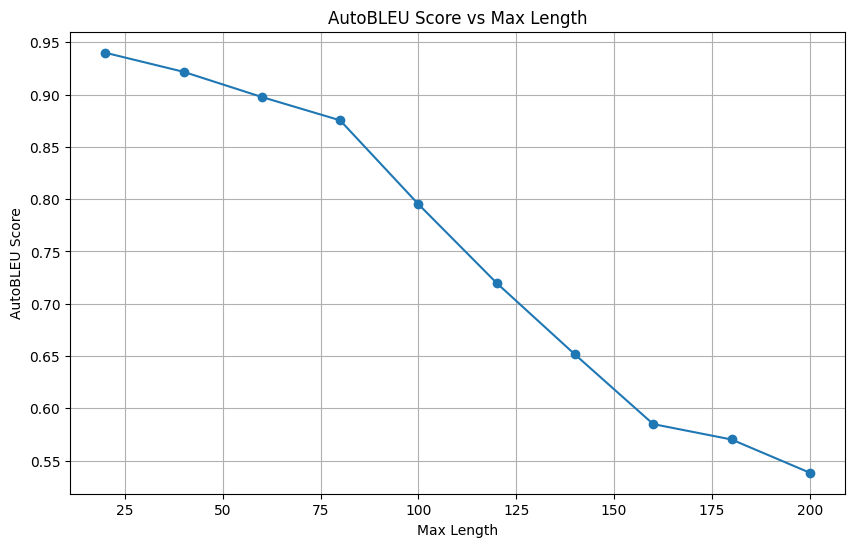

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(scores.keys(), scores.values(), marker='o', linestyle='-')
plt.title('AutoBLEU Score vs Max Length')
plt.xlabel('Max Length')
plt.ylabel('AutoBLEU Score')
plt.grid(True)
plt.show()